In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
df = pl.read_csv('data/MrBeast_youtube_stats.csv')

In [3]:
df.group_by('id').agg(pl.col('title').n_unique()).sort('title', descending=True)

id,title
str,u32
null,12
"""0CTp1a-aCUM""",5
"""65fN_OUawjk""",4
"""2isYuQZMbdU""",4
"""vBpQ1SlfVtU""",4
…,…
"""P4qWhSZ7_WA""",1
"""MLN6TRB9Jxw""",1
"""VN2-3OfUzd8""",1


In [4]:
df = df.with_columns(pl.col('pull_date').str.to_datetime(format='%Y-%m-%d %H:%M:%S%.f%:z'))

<Axes: title={'center': 'Number of Videos pulled per day'}, xlabel='pull_date'>

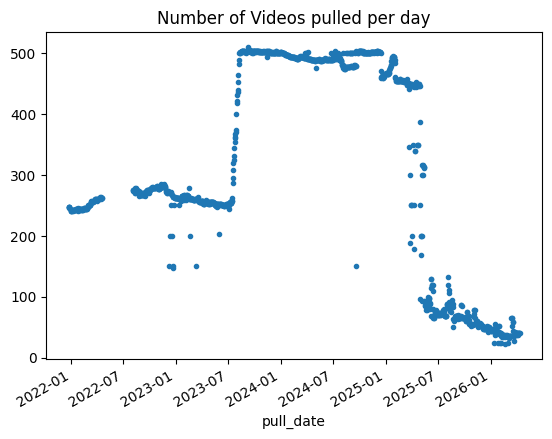

In [5]:
(df['pull_date'].value_counts()
    .sort('pull_date')
    .to_pandas()
    .set_index('pull_date')['count']
    .plot(style='.', title='Number of Videos pulled per day'))

In [6]:
df = df.drop_nulls(subset=['viewCount'])
df = df.with_columns(pl.col('viewCount').cast(pl.Int64))

In [7]:
(df.group_by(['id', 'title'])
    .agg(
        pl.col('viewCount').max(),
        pl.col('pull_date').max()
    )
    .sort('viewCount'))

id,title,viewCount,pull_date
str,str,i64,"datetime[μs, UTC]"
"""F3fmzCmIJ14""","""This Stream Ends When Someone …",0,2026-04-05 00:06:18.400542 UTC
"""TGKkMl17Htg""","""Battle Pirates, Unstoppable Sh…",35956,2023-08-07 00:09:55.117235 UTC
"""ywZy_Fo2ydo""","""Modern Art Is A Joke""",36613,2023-08-27 00:12:06.324381 UTC
"""u6t4jrhs56Q""","""Top Youtube &quot;ShoutOuts&qu…",36633,2023-08-27 00:12:06.324381 UTC
"""6T17licWsQ4""","""Leaving For 7 Days""",39197,2023-07-24 00:13:41.788641 UTC
…,…,…,…
"""0e3GPea1Tyg""","""$456,000 Squid Game In Real Li…",912902741,2026-03-16 00:05:43.552049 UTC
"""L5kIXRdwGAI""","""Katana Vs Bullet""",1085305868,2025-10-18 00:02:51.349756 UTC
"""IQxea9UB1nQ""","""$100,000,000 Car Doors""",1186290758,2025-08-18 00:04:33.009006 UTC


<Axes: xlabel='pull_date'>

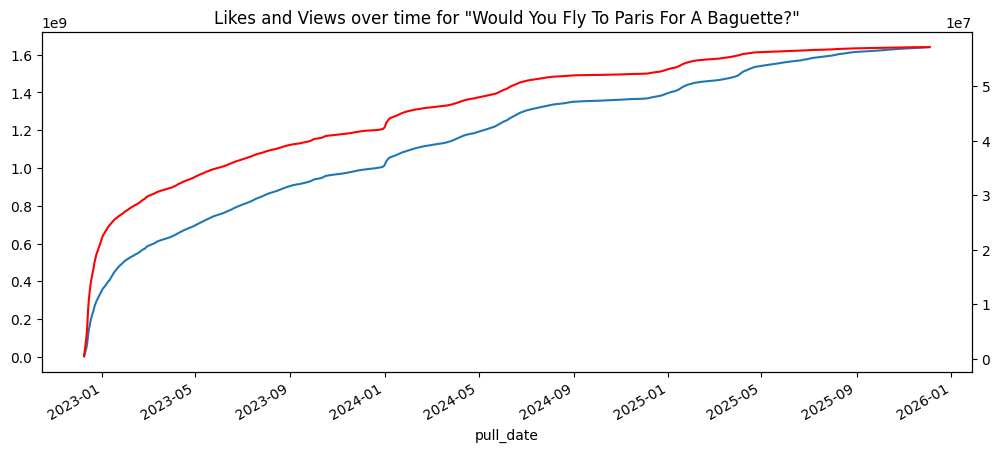

In [8]:
video_name = df.filter(pl.col('id') == 'se50viFJ0AQ')['title'][0]
video_df = df.filter(pl.col('id') == 'se50viFJ0AQ').to_pandas().set_index('pull_date')
fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
video_df['viewCount'].plot(
    ax=ax,
    title=f'Likes and Views over time for "{video_name}"')
video_df['likeCount'].plot(ax=ax2, color='red')

In [9]:
df = pl.read_parquet('data/MrBeast_youtube_stats_processed.parquet')

In [10]:
df = df.with_columns(
    (pl.col('like_diff') / pl.col('view_diff')).alias('like_to_view_ratio')
)

In [11]:
df.filter(pl.col('view_diff') != 0).sort('like_to_view_ratio', descending=True)

id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.url,thumbnails.default.width,thumbnails.default.height,thumbnails.medium.url,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.url,thumbnails.high.width,thumbnails.high.height,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date,time_since_last_pull,view_diff,like_diff,comment_diff,__index_level_0__,like_to_view_ratio
str,str,str,str,str,i64,i64,i64,i64,str,f64,f64,str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,"datetime[μs, UTC]",duration[μs],f64,f64,f64,i64,f64
"""uotb9ZHnI2g""","""Tipping Pizza Delivery Guys $1…","""Download Quidd - http://bit.ly…","""2017-08-23 21:44:24+00:00""","""youtube#video""",769,22178690,695773,40855,"""https://i.ytimg.com/vi/uotb9ZH…",120.0,90.0,"""https://i.ytimg.com/vi/uotb9ZH…",320.0,180.0,"""https://i.ytimg.com/vi/uotb9ZH…",480.0,360.0,"""PT12M49S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,"""['tipping pizza guys', 'tippin…",2024-05-08 00:10:49.880176 UTC,1d 34s 141142µs,309.0,695773.0,40855.0,191688,2251.692557
"""93s1JECSy60""","""Giving My Mom $100,000 (Proude…","""She started crying Download Qu…","""2017-12-02 21:10:08+00:00""","""youtube#video""",745,31480697,1529468,44545,"""https://i.ytimg.com/vi/93s1JEC…",120.0,90.0,"""https://i.ytimg.com/vi/93s1JEC…",320.0,180.0,"""https://i.ytimg.com/vi/93s1JEC…",480.0,360.0,"""PT12M25S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,"""['Giving mom 100000', 'giving …",2024-05-08 00:10:49.880176 UTC,1d 34s 141142µs,1021.0,1.529468e6,44545.0,191710,1498.009794
"""_uwNDiU04zE""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…","""2021-02-13 21:00:01+00:00""","""youtube#video""",654,55790801,3032540,146200,"""https://i.ytimg.com/vi/_uwNDiU…",120.0,90.0,"""https://i.ytimg.com/vi/_uwNDiU…",320.0,180.0,"""https://i.ytimg.com/vi/_uwNDiU…",480.0,360.0,"""PT10M54S""","""2d""","""['https://en.wikipedia.org/wik…","""en""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…",null,2024-09-21 00:07:46.820812 UTC,2d 4m 46s 558049µs,-1.0,-167.0,-44.0,126074,167.0
"""_uwNDiU04zE""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…","""2021-02-13 21:00:01+00:00""","""youtube#video""",654,55789183,3037291,149570,"""https://i.ytimg.com/vi/_uwNDiU…",120.0,90.0,"""https://i.ytimg.com/vi/_uwNDiU…",320.0,180.0,"""https://i.ytimg.com/vi/_uwNDiU…",480.0,360.0,"""PT10M54S""","""2d""","""['https://en.wikipedia.org/wik…","""en""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…",null,2024-08-05 00:06:32.183949 UTC,23h 56m 7s 619352µs,-1.0,-164.0,-70.0,148565,164.0
"""_uwNDiU04zE""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…","""2021-02-13 21:00:01+00:00""","""youtube#video""",654,55790913,3034367,147405,"""https://i.ytimg.com/vi/_uwNDiU…",120.0,90.0,"""https://i.ytimg.com/vi/_uwNDiU…",320.0,180.0,"""https://i.ytimg.com/vi/_uwNDiU…",480.0,360.0,"""PT10M54S""","""2d""","""['https://en.wikipedia.org/wik…","""en""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…",null,2024-09-01 00:06:15.728579 UTC,23h 56m 12s 239023µs,-5.0,-393.0,-8.0,135275,78.6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""_uwNDiU04zE""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…","""2021-02-13 21:00:01+00:00""","""youtube#video""",654,55791102,3034167,147346,"""https://i.ytimg.com/vi/_uwNDiU…",120.0,90.0,"""https://i.ytimg.com/vi/_uwNDiU…",320.0,180.0,"""https://i.ytimg.com/vi/_uwNDiU…",480.0,360.0,"""PT10M54S""","""2d""","""['https://en.wikipedia.org/wik…","""en""","""I Donated $300,000 To People I…","""Subscribe and I'll Donate $0.1…",null,2024-09-03 00:06:29.369809 UTC,1d 1s 502275µs,1.0,-73.0,-44.0,134315,-73.0
"""_uwNDiU04zE""","""I Donated

<Axes: xlabel='pull_date'>

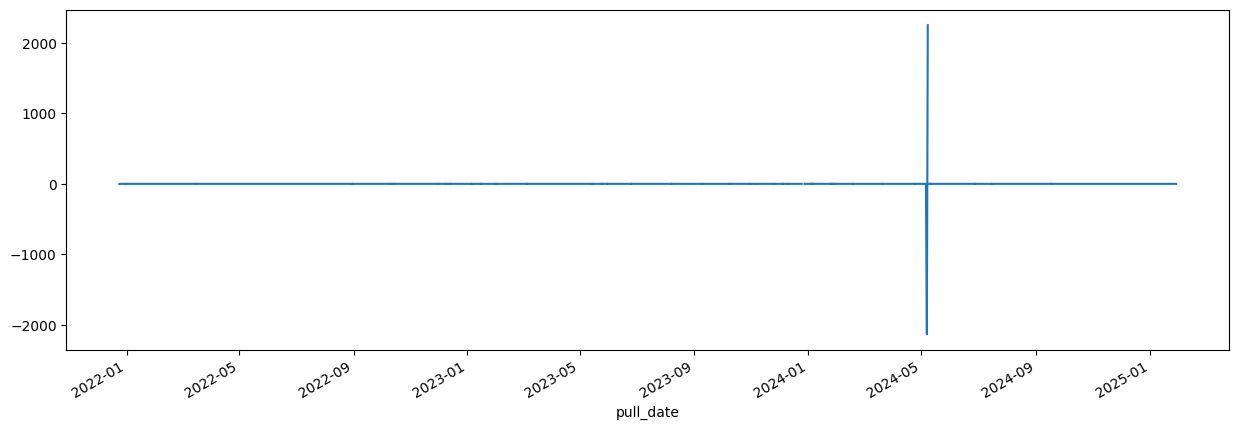

In [12]:
(df.filter(pl.col('id') == 'uotb9ZHnI2g')
    .to_pandas()
    .set_index('pull_date')['like_to_view_ratio']
    .plot(figsize=(15, 5)))

In [13]:
df = df.with_columns(
    (pl.col('view_diff') / (pl.col('time_since_last_pull').dt.total_seconds() / (60 * 60 * 12))).alias('view_diff_norm')
)

In [14]:
df = df.with_columns(
    (pl.col('like_diff') / (pl.col('time_since_last_pull').dt.total_seconds() / (60 * 60 * 12))).alias('like_diff_norm')
)

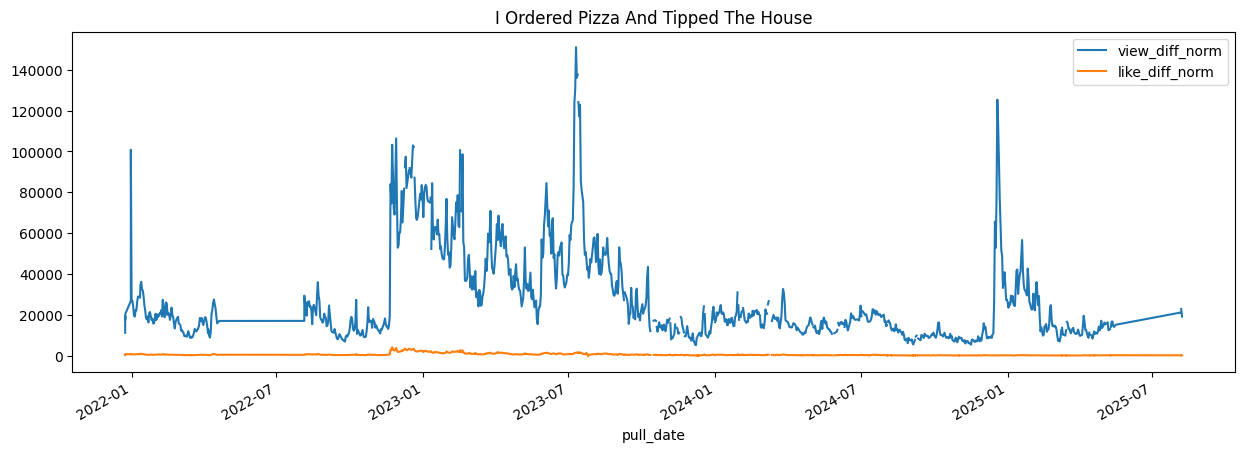

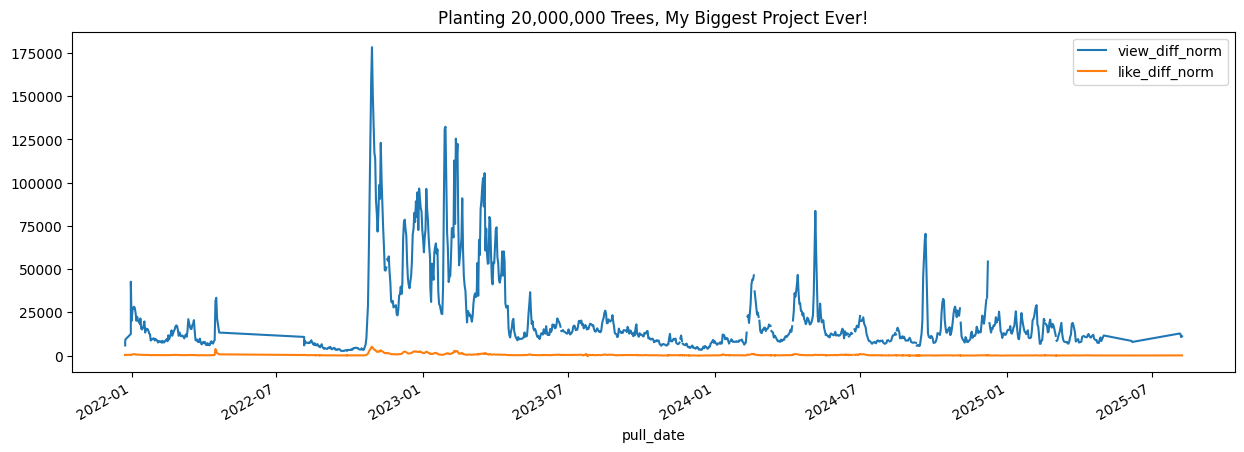

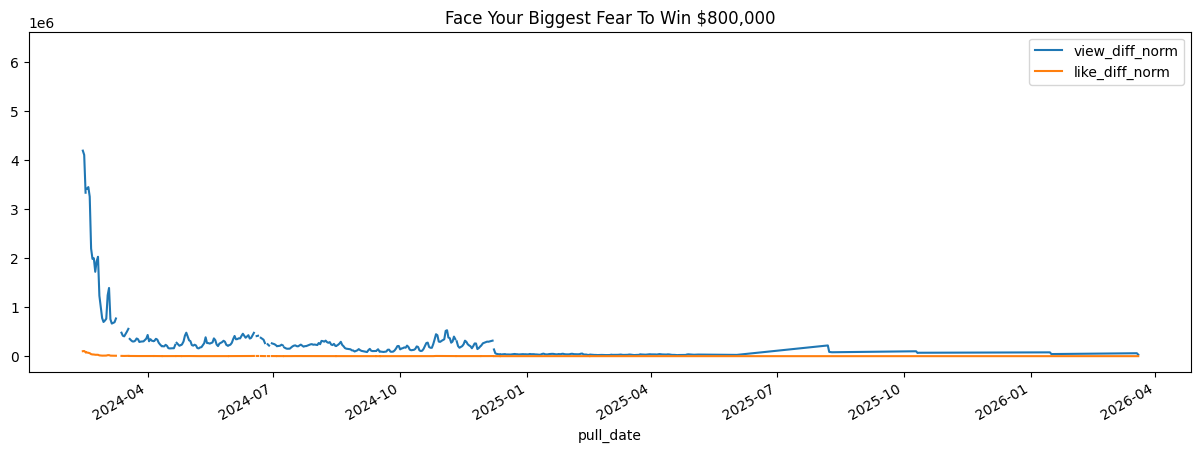

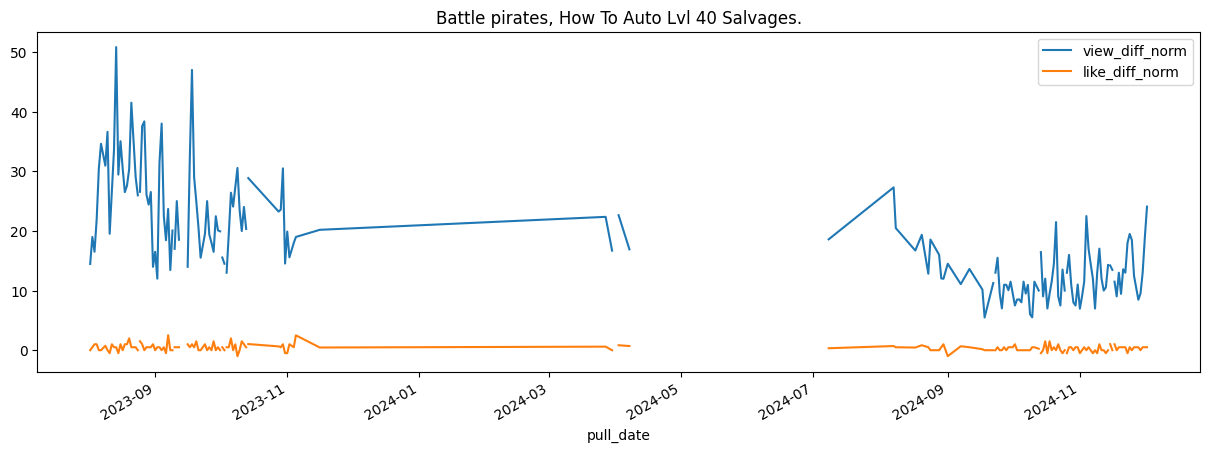

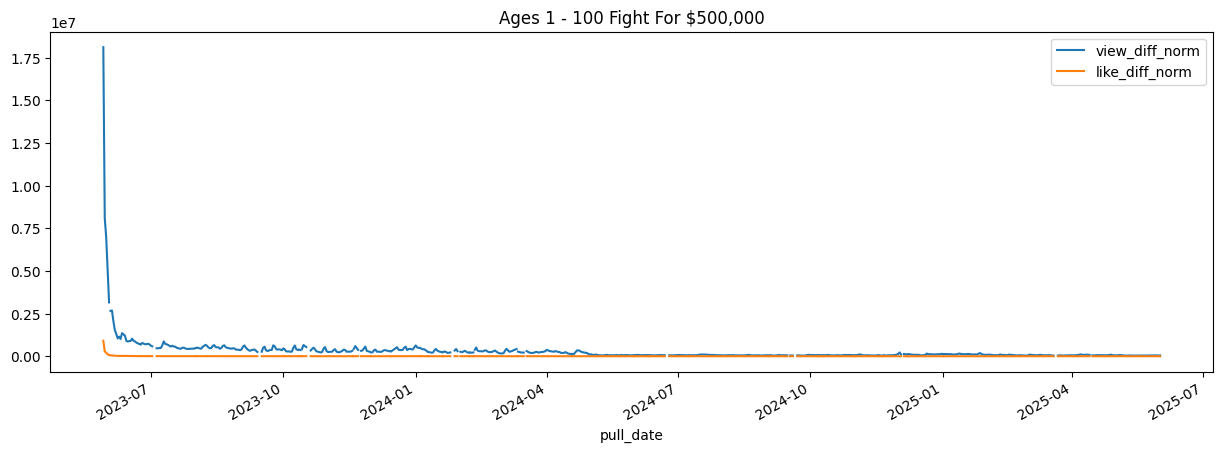

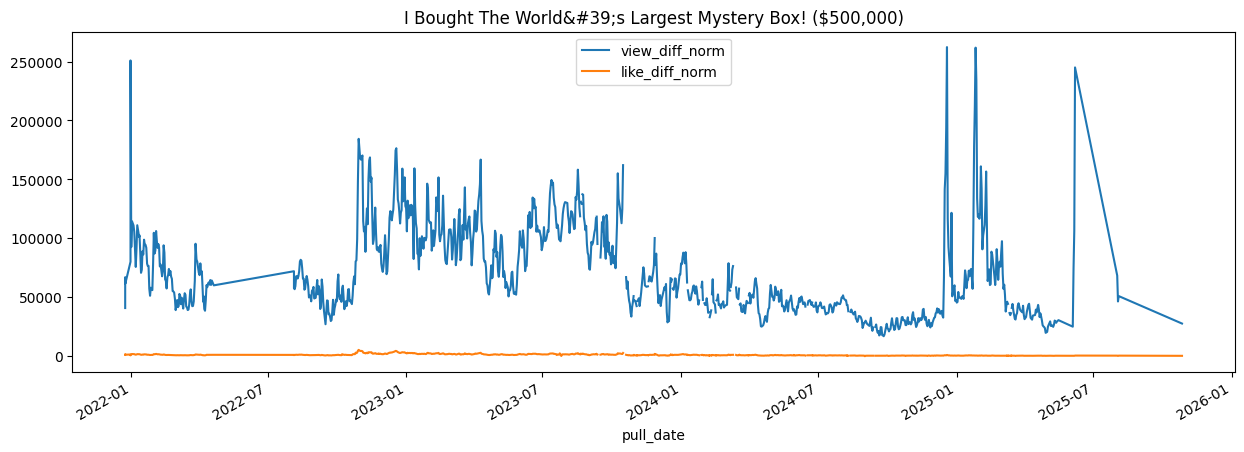

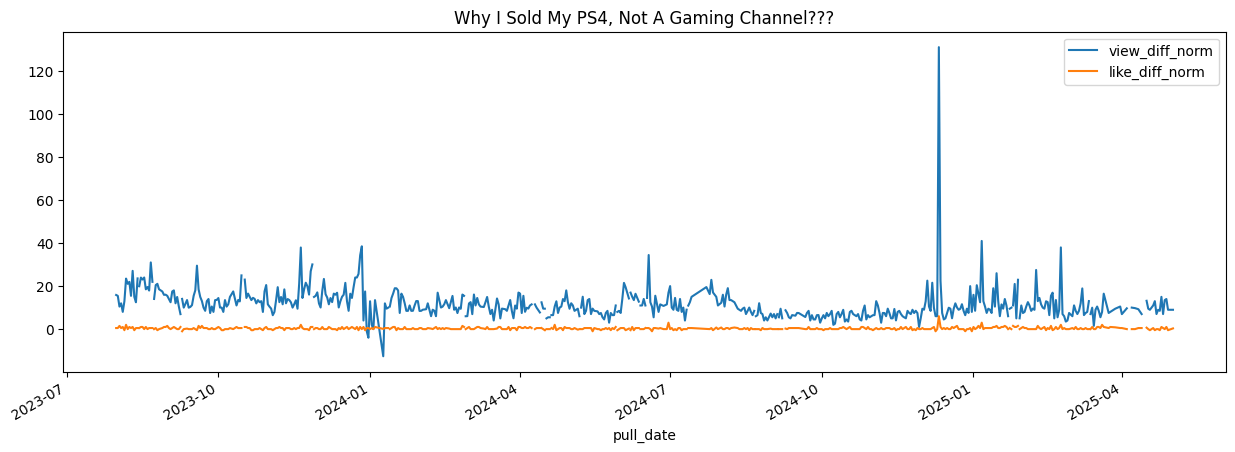

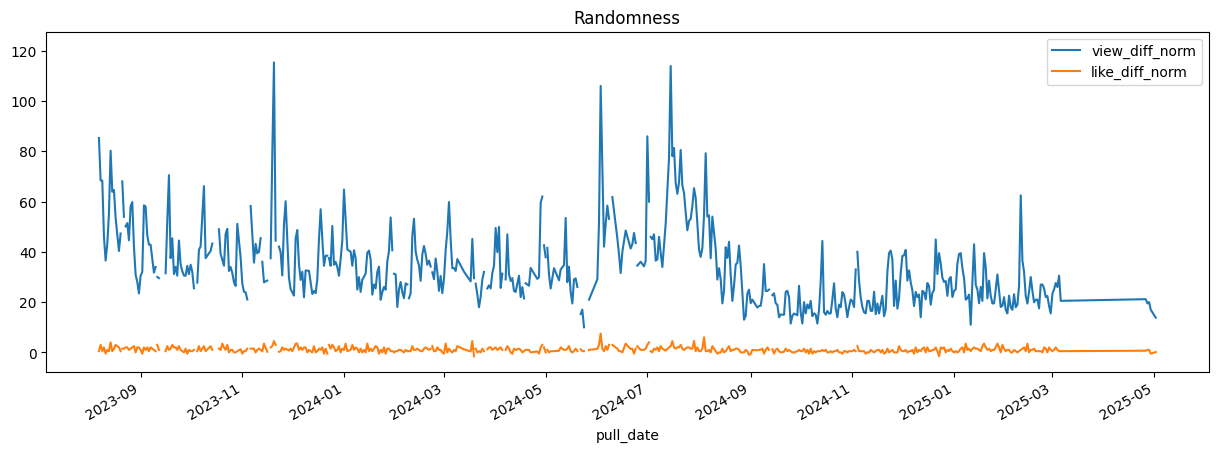

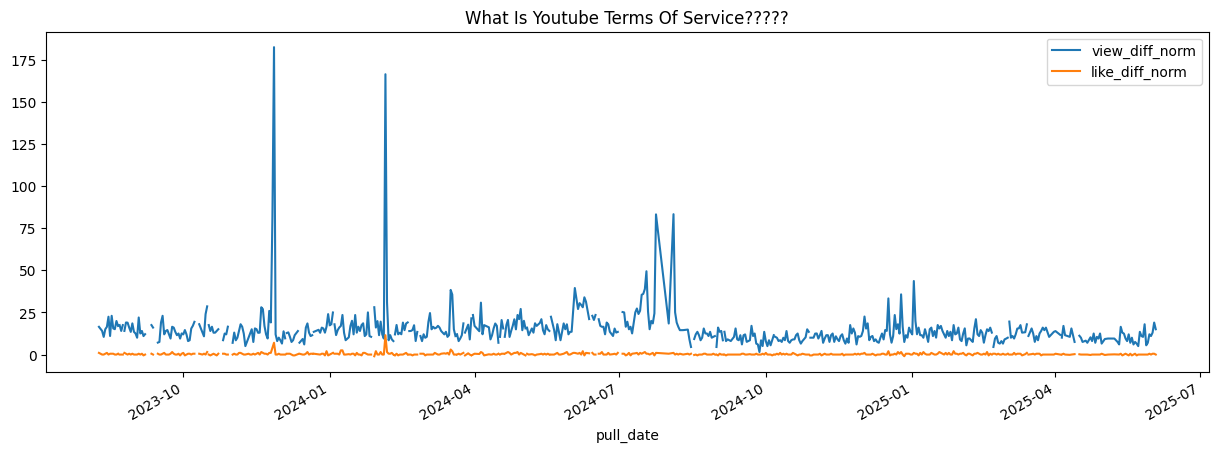

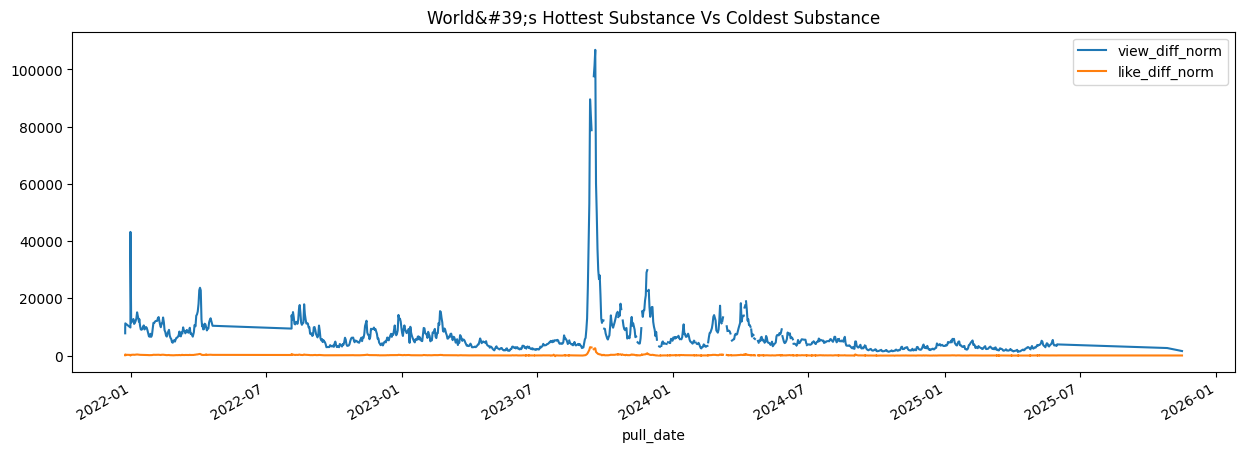

In [15]:
random_vids = df['id'].sample(10, seed=529).to_list()

for v in random_vids:
    title = df.filter(pl.col('id') == v)['title'][0]
    (df.filter(pl.col('id') == v)
        .sort('pull_date')
        .to_pandas()
        .set_index('pull_date')[['view_diff_norm', 'like_diff_norm']]
        .plot(figsize=(15, 5), title=title))

## Look at videos with crazy ratios

In [16]:
df = df.with_columns(
    (pl.col('like_diff_norm') / pl.col('view_diff_norm')).alias('like_ratio_norm')
)

In [17]:
top_10 = (df.filter((pl.col('like_ratio_norm') <= 1) & (pl.col('view_diff_norm') != 0))
    .group_by('title')
    .agg(pl.col('like_ratio_norm').max())
    .sort('like_ratio_norm', descending=True))

In [18]:
top_10

title,like_ratio_norm
str,f64
"""I Gave $500,000 To Random Peop…",1.0
"""How To Become A Gaming Youtube…",1.0
"""I Donated $300,000 To People I…",1.0
"""Knives In Video Games Cost Mor…",1.0
"""5$ To Advertise Your Youtube C…",1.0
…,…
"""World&#39;s Biggest YouTubers …",-0.000384
"""Get Every Boy Scout Badge, Win…",-0.006398
"""Making Fun Of Youtuber&#39;s I…",-0.013158


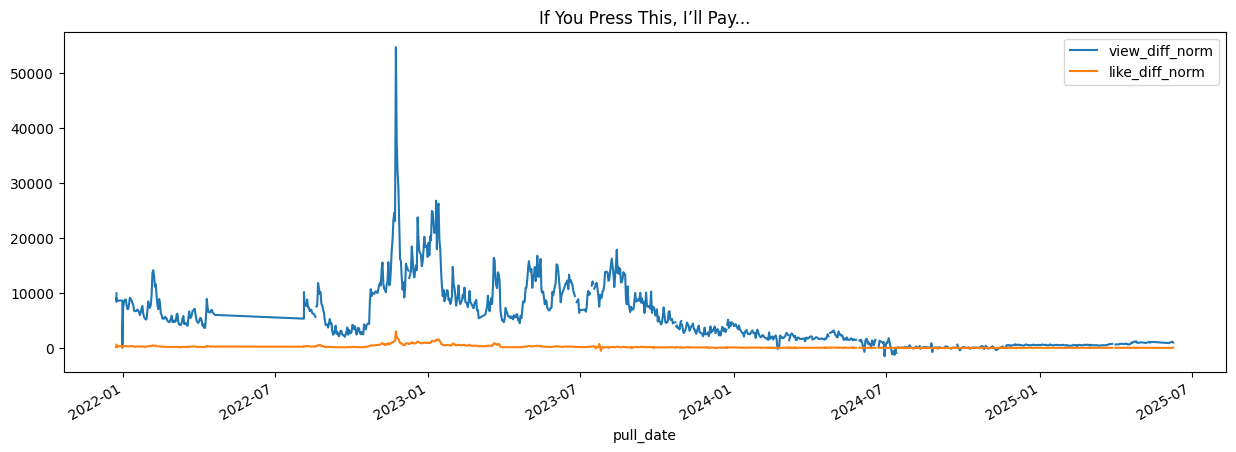

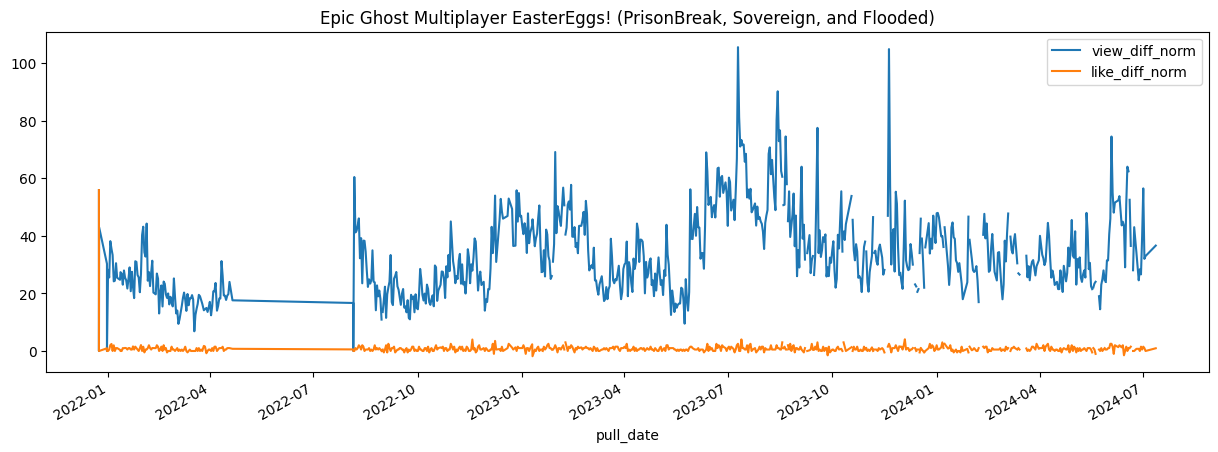

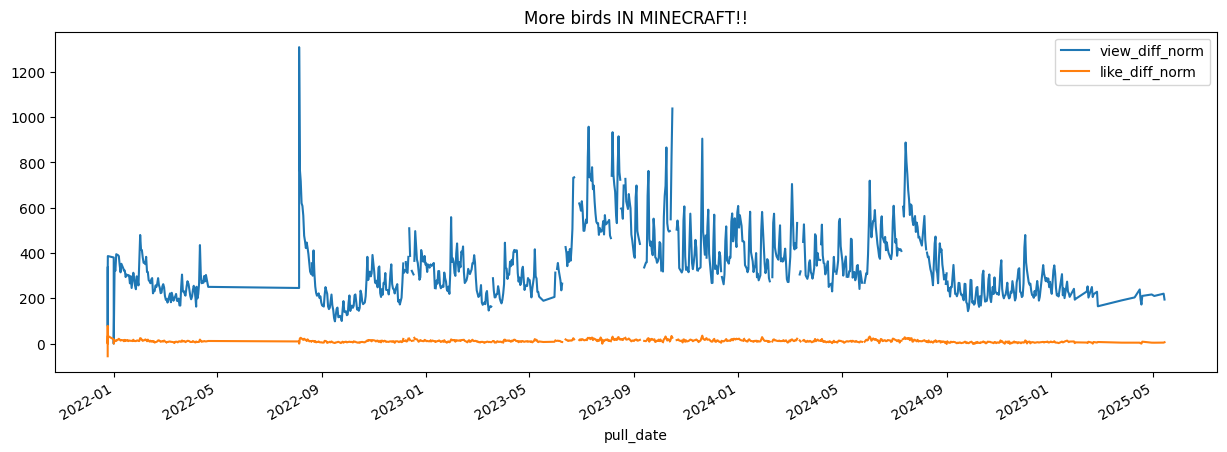

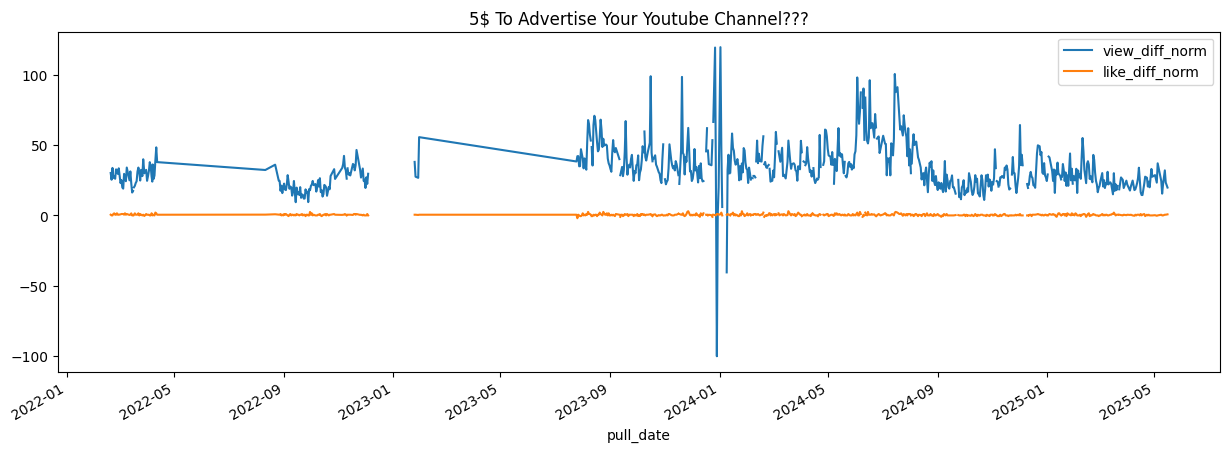

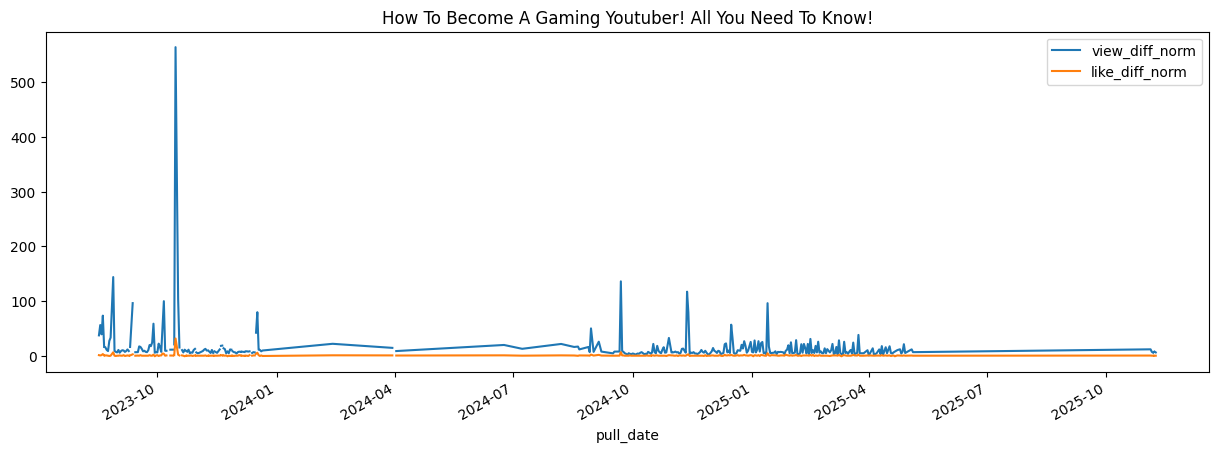

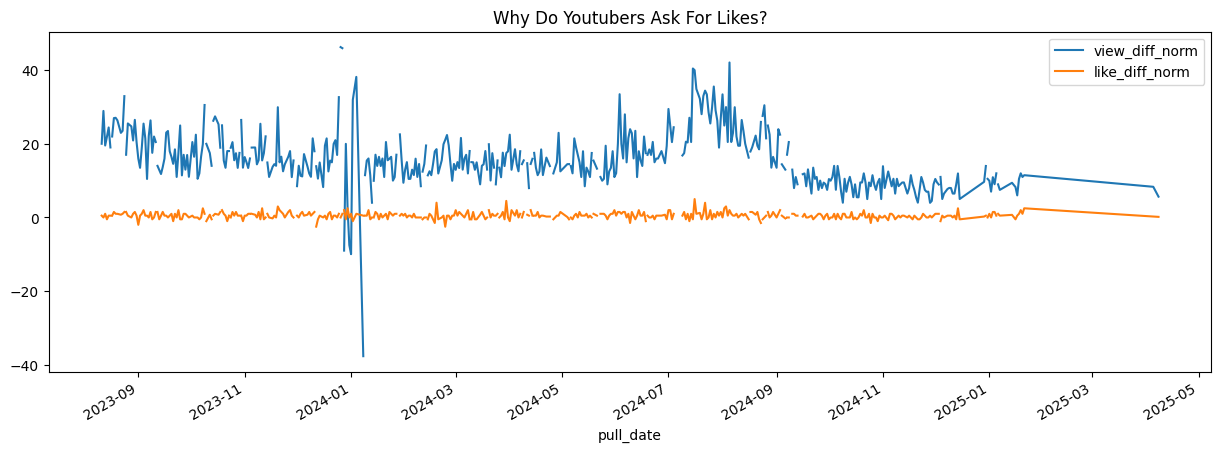

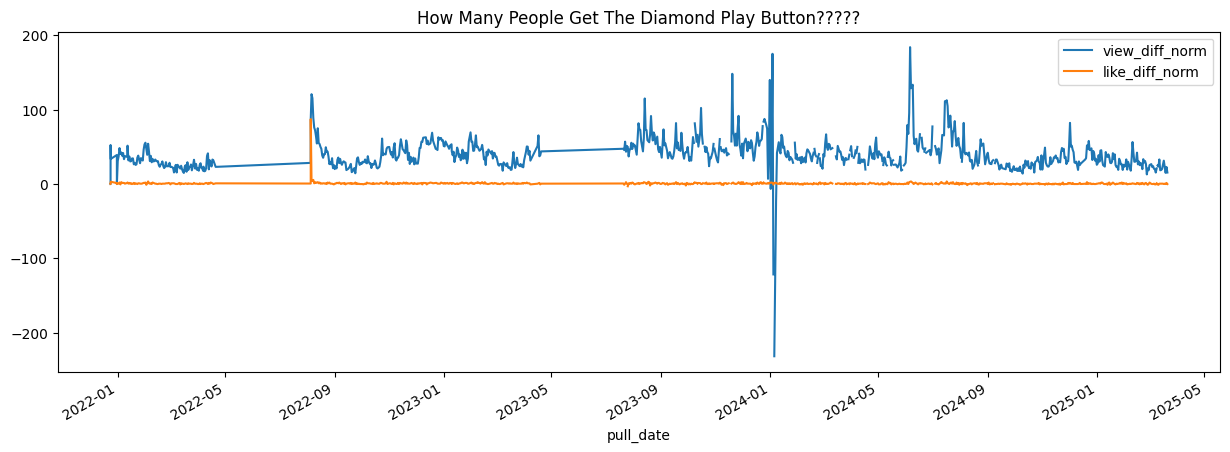

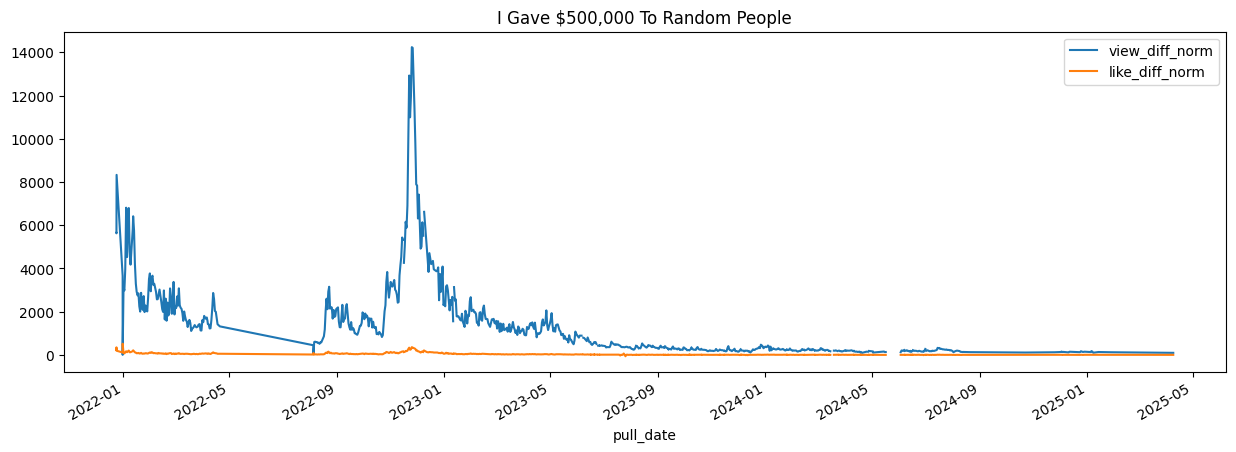

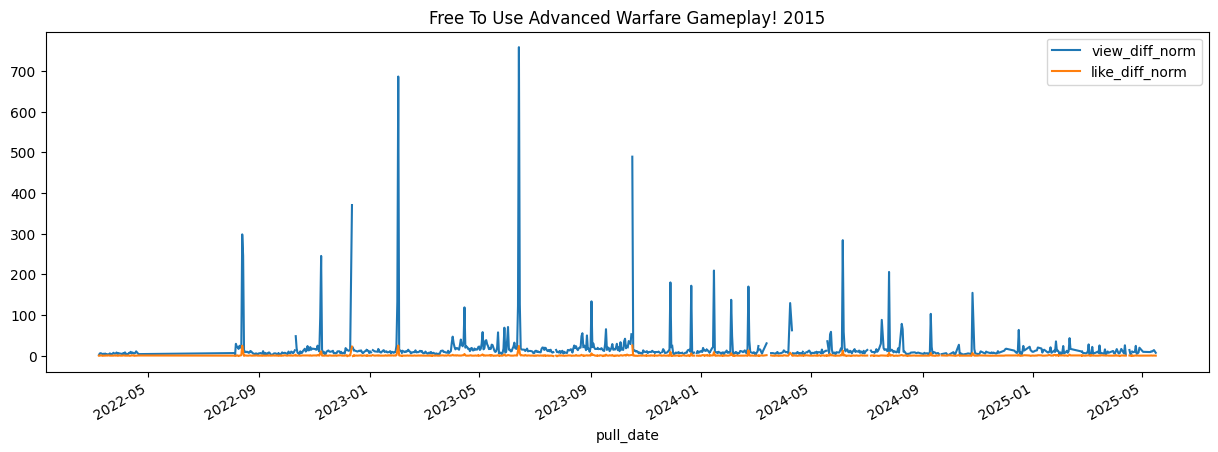

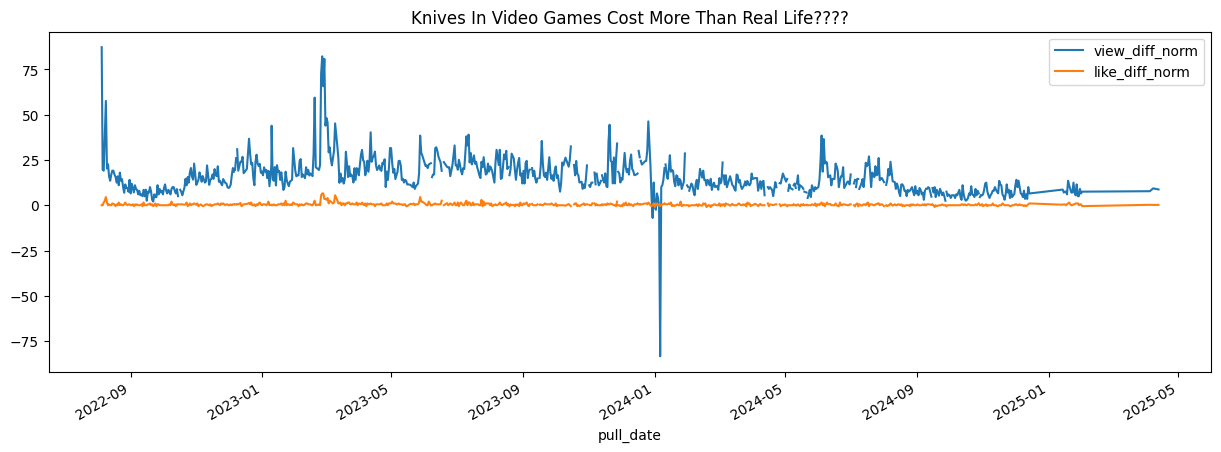

In [19]:
top_10_ids = (df.filter((pl.col('like_ratio_norm') <= 1) & (pl.col('view_diff_norm') != 0))
    .group_by('id')
    .agg(pl.col('like_ratio_norm').max())
    .sort('like_ratio_norm', descending=True)['id']
    [:10]
    .to_list())

for v in top_10_ids:
    title = df.filter(pl.col('id') == v)['title'][0]
    (df.filter(pl.col('id') == v)
        .sort('pull_date')
        .to_pandas()
        .set_index('pull_date')[['view_diff_norm', 'like_diff_norm']]
        .plot(figsize=(15, 5), title=title))

In [20]:
df.filter(pl.col('id') == 'se50viFJ0AQ').select(['viewCount', 'likeCount']).to_pandas().corr()

,viewCount,likeCount
viewCount,1.000000,0.992915
likeCount,0.992915,1.000000


In [21]:
pl.Config.set_tbl_cols(50)
df

id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.url,thumbnails.default.width,thumbnails.default.height,thumbnails.medium.url,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.url,thumbnails.high.width,thumbnails.high.height,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date,time_since_last_pull,view_diff,like_diff,comment_diff,__index_level_0__,like_to_view_ratio,view_diff_norm,like_diff_norm,like_ratio_norm
str,str,str,str,str,i64,i64,i64,i64,str,f64,f64,str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,"datetime[μs, UTC]",duration[μs],f64,f64,f64,i64,f64,f64,f64,f64
"""-0zoWMSEOGg""","""I Gave My 6,000,000th Subscrib…","""YOU WON'T BELIEVE WHAT WE GAVE…","""2018-07-25 21:11:00+00:00""","""youtube#video""",1113,15052568,353973,33234,"""https://i.ytimg.com/vi/-0zoWMS…",120.0,90.0,"""https://i.ytimg.com/vi/-0zoWMS…",320.0,180.0,"""https://i.ytimg.com/vi/-0zoWMS…",480.0,360.0,"""PT18M33S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,null,2021-12-24 01:41:03.667334 UTC,null,null,null,null,454695,null,null,null,null
"""-0zoWMSEOGg""","""I Gave My 6,000,000th Subscrib…","""YOU WON'T BELIEVE WHAT WE GAVE…","""2018-07-25 21:11:00+00:00""","""youtube#video""",1113,15052587,353973,33234,"""https://i.ytimg.com/vi/-0zoWMS…",120.0,90.0,"""https://i.ytimg.com/vi/-0zoWMS…",320.0,180.0,"""https://i.ytimg.com/vi/-0zoWMS…",480.0,360.0,"""PT18M33S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,null,2021-12-24 01:53:57.197204 UTC,12m 53s 529870µs,19.0,0.0,0.0,454448,0.0,1061.836999,0.0,0.0
"""-0zoWMSEOGg""","""I Gave My 6,000,000th Subscrib…","""YOU WON'T BELIEVE WHAT WE GAVE…","""2018-07-25 21:11:00+00:00""","""youtube#video""",1113,15052593,353973,33234,"""https://i.ytimg.com/vi/-0zoWMS…",120.0,90.0,"""https://i.ytimg.com/vi/-0zoWMS…",320.0,180.0,"""https://i.ytimg.com/vi/-0zoWMS…",480.0,360.0,"""PT18M33S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,null,2021-12-24 02:03:09.197822 UTC,9m 12s 618µs,6.0,0.0,0.0,454207,0.0,469.565217,0.0,0.0
"""-0zoWMSEOGg""","""I Gave My 6,000,000th Subscrib…","""YOU WON'T BELIEVE WHAT WE GAVE…","""2018-07-25 21:11:00+00:00""","""youtube#video""",1113,15052597,353973,33234,"""https://i.ytimg.com/vi/-0zoWMS…",120.0,90.0,"""https://i.ytimg.com/vi/-0zoWMS…",320.0,180.0,"""https://i.ytimg.com/vi/-0zoWMS…",480.0,360.0,"""PT18M33S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,null,2021-12-24 02:16:53.157735 UTC,13m 43s 959913µs,4.0,0.0,0.0,453955,0.0,209.963548,0.0,0.0
"""-0zoWMSEOGg""","""I Gave My 6,000,000th Subscrib…","""YOU WON'T BELIEVE WHAT WE GAVE…","""2018-07-25 21:11:00+00:00""","""youtube#video""",1113,15052769,353975,33234,"""https://i.ytimg.com/vi/-0zoWMS…",120.0,90.0,"""https://i.ytimg.com/vi/-0zoWMS…",320.0,180.0,"""https://i.ytimg.com/vi/-0zoWMS…",480.0,360.0,"""PT18M33S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,null,2021-12-24 06:11:36.043167 UTC,3h 54m 42s 885432µs,172.0,2.0,0.0,453707,0.011628,527.652322,6.135492,0.011628
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""zxuICI0kL3s""","""Don’t Turn Around, Win $10k""",null,"""2025-07-31 16:00:01+00:00""","""youtube#video""",31,158436656,3666206,5532,"""https://i.ytimg.com/vi/zxuICI0…",120.0,90.0,"""https://i.ytimg.com/vi/zxuICI0…",320.0,180.0,"""https://i.ytimg.com/vi/zxuICI0…",480.0,360.0,"""PT31S""","""2d""","""['https://en.wikipedia.org/wik…","""en""","""Don’t Turn Around, Win $10k""",null,null,2025-08-06 00:03:02.430098 UTC,1d 54s 740390µs,1.1132526e7,225526.0,273.0,12652,0.020258,5.5628e6,112692.567146,0.020258
"""zxuICI0kL3s""","""Don’t Turn Around, Win $10k""",null,"""2025-07-31 16:00:01+00:00""","""youtube#video""",31,165692474,3798626,5612,"""https://i.ytimg.com/vi/zxuICI0…",120.0,90.0,"""https://i.ytimg.com/vi/zxuICI0…",320.

<Axes: ylabel='Frequency'>

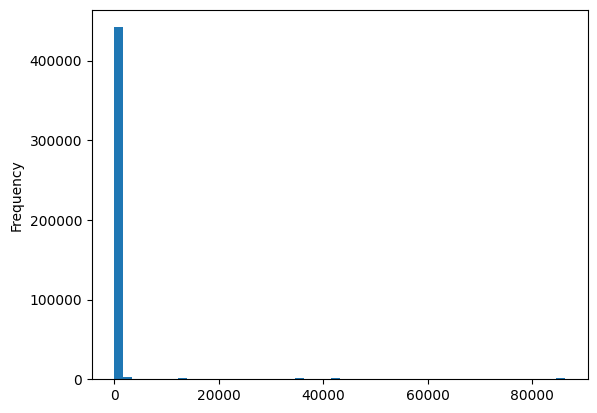

In [22]:
df['duration_seconds'].to_pandas().plot(kind='hist', bins=50)

<Axes: ylabel='Frequency'>

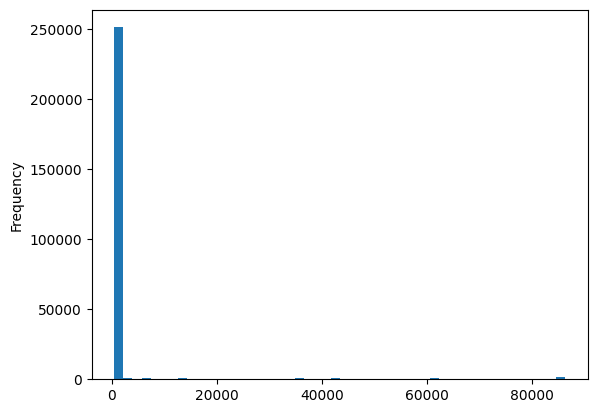

In [23]:
df.filter(pl.col('duration_seconds') > 500)['duration_seconds'].to_pandas().plot(kind='hist', bins=50)

In [24]:
df_vid = df.sort('pull_date', descending=True).group_by('id').head(1)

In [25]:
df_vid = df_vid.with_columns(
    (pl.col('commentCount') / pl.col('viewCount')).alias('comment_ratio')
)

In [26]:
df_vid.filter(pl.col('viewCount') > 1_000_000).sort('comment_ratio', descending=True)

id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.url,thumbnails.default.width,thumbnails.default.height,thumbnails.medium.url,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.url,thumbnails.high.width,thumbnails.high.height,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date,time_since_last_pull,view_diff,like_diff,comment_diff,__index_level_0__,like_to_view_ratio,view_diff_norm,like_diff_norm,like_ratio_norm,comment_ratio
str,str,str,str,str,i64,i64,i64,i64,str,f64,f64,str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,"datetime[μs, UTC]",duration[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64
"""TRiF8PdrIP8""","""MrBeast6000&#39;s Channel Trai…","""CLICK THIS LINK FOR PIE! - htt…","""2015-10-08 20:00:00+00:00""","""youtube#video""",115,1601062,125779,13256,"""https://i.ytimg.com/vi/TRiF8Pd…",120.0,90.0,"""https://i.ytimg.com/vi/TRiF8Pd…",320.0,180.0,"""https://i.ytimg.com/vi/TRiF8Pd…",480.0,360.0,"""PT1M55S""","""2d""",null,null,null,null,"""['Mr.Beast', 'mr', 'beast']""",2024-07-19 00:09:23.657625 UTC,23h 58m 29s 632152µs,289.0,5.0,1.0,156870,0.017301,144.652354,2.502636,0.017301,0.00828
"""mGIpOtncmSM""","""Saying Pewdiepie 100,000 Times""","""I SAID HIS NAME 100000 TIMES T…","""2018-11-25 21:07:01+00:00""","""youtube#video""",42520,26527541,1694626,167235,"""https://i.ytimg.com/vi/mGIpOtn…",120.0,90.0,"""https://i.ytimg.com/vi/mGIpOtn…",320.0,180.0,"""https://i.ytimg.com/vi/mGIpOtn…",480.0,360.0,"""PT11H48M40S""","""2d""",null,null,null,null,null,2025-05-02 00:10:08.821562 UTC,3d 6m 25s 265704µs,1815.0,-70.0,-9.0,23183,-0.038567,302.051351,-11.649363,-0.038567,0.006304
"""5J6-5g2alp8""","""100,000 SUBSCRIBERS.EXE""","""I never thought this many peop…","""2016-07-08 20:00:00+00:00""","""youtube#video""",266,1440272,80380,7891,"""https://i.ytimg.com/vi/5J6-5g2…",120.0,90.0,"""https://i.ytimg.com/vi/5J6-5g2…",320.0,180.0,"""https://i.ytimg.com/vi/5J6-5g2…",480.0,360.0,"""PT4M26S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,"""['100000 subscribers', '100k s…",2024-08-27 00:08:15.885955 UTC,19d 5s 909772µs,7122.0,156.0,-166.0,138013,0.021904,187.420482,4.105251,0.021904,0.005479
"""v1ELS84GQu8""","""If This Video Gets One Million…","""Be a dear and share this with …","""2013-09-07 02:28:05+00:00""","""youtube#video""",46,13155416,1173452,71958,"""https://i.ytimg.com/vi/v1ELS84…",120.0,90.0,"""https://i.ytimg.com/vi/v1ELS84…",320.0,180.0,"""https://i.ytimg.com/vi/v1ELS84…",480.0,360.0,"""PT46S""","""2d""",null,null,null,null,null,2025-04-29 00:03:43.555858 UTC,1d 34s 404358µs,579.0,-18.0,-1.0,23898,-0.031088,289.386121,-8.99646,-0.031088,0.00547
"""fG1N5kzeAhM""","""Dear Future Me (Scheduled Uplo…","""Dear future me, please do not …","""2016-04-04 19:30:01+00:00""","""youtube#video""",145,2359615,134610,12523,"""https://i.ytimg.com/vi/fG1N5kz…",120.0,90.0,"""https://i.ytimg.com/vi/fG1N5kz…",320.0,180.0,"""https://i.ytimg.com/vi/fG1N5kz…",480.0,360.0,"""PT2M25S""","""2d""",null,null,null,null,"""['Mr.Beast', 'mr', 'beast']""",2025-02-13 00:02:01.489061 UTC,23h 59m 28s 775447µs,370.0,9.0,0.0,55233,0.024324,185.068544,4.501667,0.024324,0.005307
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""k194wHZHjB0""","""Most Expensive Hand Model Hold…",null,"""2024-02-24 18:00:09+00:00""","""youtube#video""",22,430388949,10863360,8204,"""https://i.ytimg.com/vi/k194wHZ…",120.0,90.0,"""https://i.ytimg.com/vi/k194wHZ…",320.0,180.0,"""https://i.ytimg.com/vi/k194wHZ…",480.0,360.0,"""PT22S""","""2d""","""['https://en.wikipedia.org/wik…",null,null,null,null,2025-06-08 00:07:05.311499 UTC,1d 5m 18s 74506µs,973023.0,6950.0,7.0,17269,0.007143,484727.433751,3462.256971,0.007143,0.000019
"""qtWqHIx8Z-o""","""Last Person Standing Wins $10,…",null,"""2024-12-22 17:00:01+00:00""","""youtube#video""",48,450083823,1147